# Minería de datos 2027-1
## Redes neuronales MLP II · Arquitectura, aprendizaje y experimentación con PySpark

**Continuidad del notebook:** *Redes neuronales con PySpark y MLlib*  
**Curso:** Minería de datos  
**Profesor:** Dr. Ulises Olivares


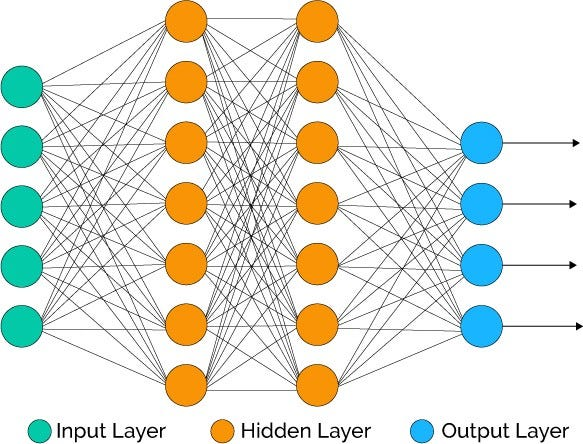

## 0. Contexto visual y datos reales

En esta continuación trabajaremos con **datasets reales y públicos incluidos en scikit-learn**, evitando depender de datos sintéticos para los experimentos principales.

El caso central continúa siendo **Digits**, una colección de imágenes digitalizadas de dígitos manuscritos. Cada imagen tiene $8	imes8$ píxeles, por lo que cada observación se representa mediante **64 características numéricas** y una etiqueta de clase de 0 a 9.

La siguiente figura está construida directamente con observaciones del dataset que utilizaremos en el notebook.


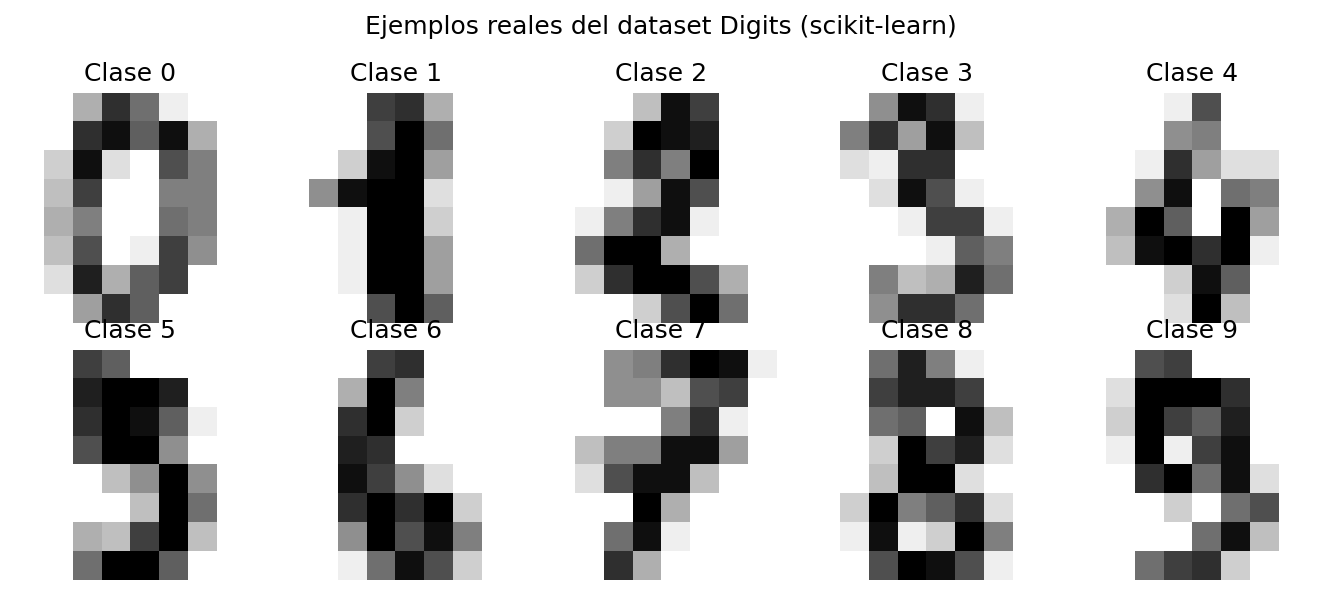

**Figura.** Diez observaciones reales de `sklearn.datasets.load_digits`, una por clase.


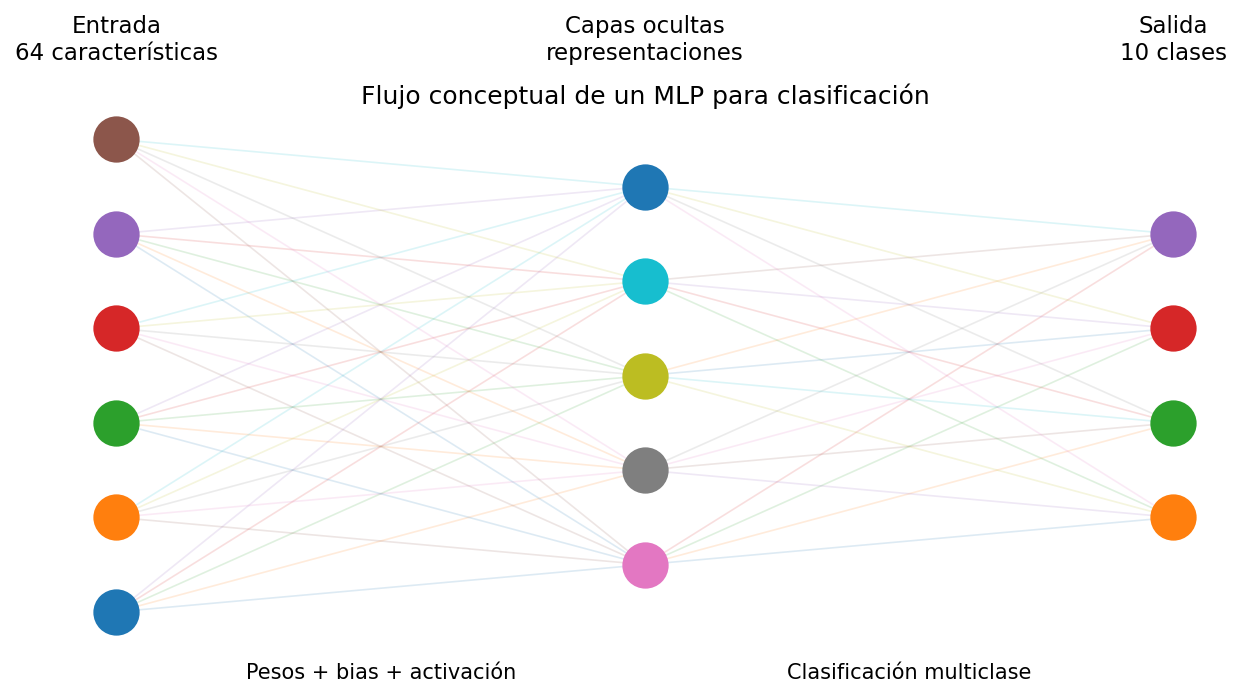

**Figura.** Representación ilustrativa del flujo de información en un MLP. En nuestro caso, las 64 intensidades de píxel forman la entrada y las 10 clases de dígitos forman la salida.


## 1. De una neurona a una red

Una neurona artificial calcula primero una combinación lineal:

$z = \mathbf{w}^{T}\mathbf{x} + b$

y posteriormente aplica una función de activación:

$a = g(z)$

Una capa repite este proceso con varias neuronas. En forma matricial:

$\mathbf{z}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$

$\mathbf{a}^{(l)} = g(\mathbf{z}^{(l)})$

El punto importante es que **las capas ocultas permiten construir representaciones no lineales**.

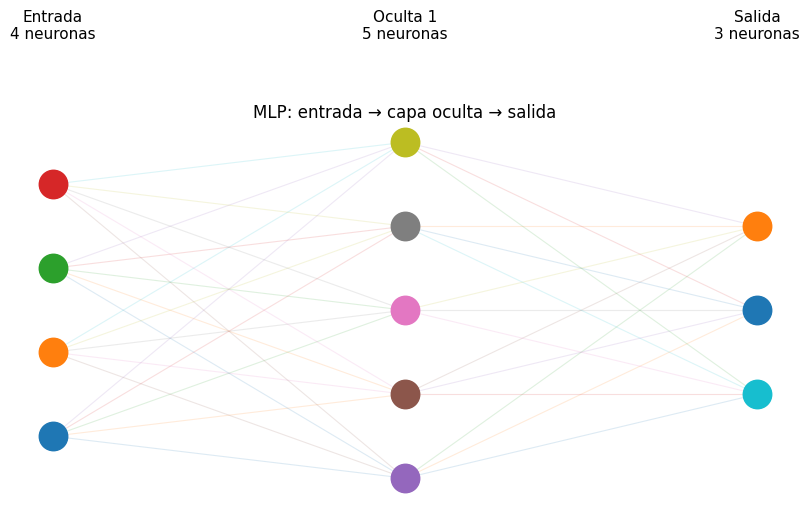

In [ ]:
# Diagrama autocontenido: arquitectura de un MLP pequeño
import matplotlib.pyplot as plt

def dibujar_mlp(capas=(4, 5, 3), titulo="MLP: entrada → capa oculta → salida"):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    xs = list(range(len(capas)))
    posiciones = []
    for x, n in zip(xs, capas):
        ys = [i - (n-1)/2 for i in range(n)]
        posiciones.append([(x, y) for y in ys])

    for l in range(len(capas)-1):
        for x1, y1 in posiciones[l]:
            for x2, y2 in posiciones[l+1]:
                ax.plot([x1, x2], [y1, y2], alpha=.15, linewidth=.8)

    for l, pos in enumerate(posiciones):
        for x, y in pos:
            ax.scatter(x, y, s=420, zorder=3)
        etiqueta = "Entrada" if l == 0 else ("Salida" if l == len(capas)-1 else f"Oculta {l}")
        ax.text(l, max(capas)/2 + .7, f"{etiqueta}\n{capas[l]} neuronas",
                ha="center", va="bottom", fontsize=11)

    ax.set_title(titulo)
    ax.axis("off")
    plt.show()

dibujar_mlp((4, 5, 3))

### 🧠 Ejercicio 1 · Construye una neurona

Sin ejecutar código, calcula la salida de una neurona con:

$\mathbf{x}=[0.5,\;1.0,\;-0.5]$

$\mathbf{w}=[0.8,\;-0.4,\;0.2], \qquad b=0.1$

1. Calcula $z=\mathbf{w}^{T}\mathbf{x}+b$.
2. Calcula `ReLU(z) = max(0,z)`.
3. ¿Qué ocurriría si el bias fuera `-1.0`?

Escribe primero tu respuesta y después compruébala.

In [ ]:
# TODO EJERCICIO 1
import numpy as np

x = np.array([0.5, 1.0, -0.5])
w = np.array([0.8, -0.4, 0.2])
b = 0.1

# z = ...
# relu = ...

# print("z =", z)
# print("ReLU(z) =", relu)

## 2. Funciones de activación y no linealidad

Si apiláramos únicamente transformaciones lineales, varias capas seguirían siendo equivalentes a una transformación lineal. La activación introduce la **no linealidad** que permite representar relaciones más complejas.

Observemos tres activaciones conocidas. La gráfica es conceptual: el `MultilayerPerceptronClassifier` de Spark administra internamente las activaciones de su implementación.

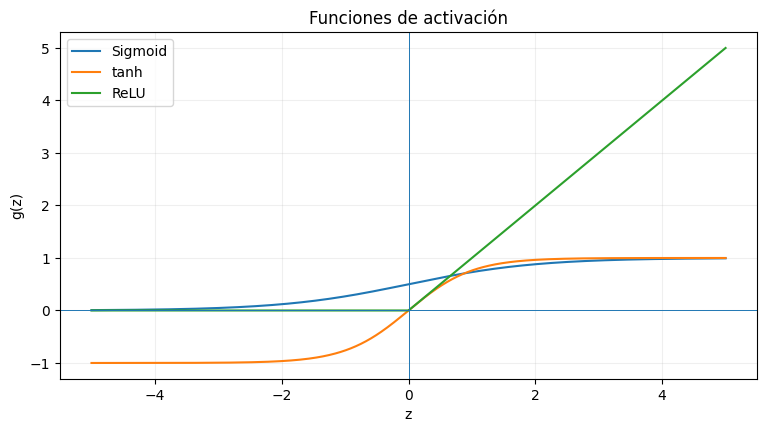

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 500)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z, sigmoid, label="Sigmoid")
ax.plot(z, tanh, label="tanh")
ax.plot(z, relu, label="ReLU")
ax.axhline(0, linewidth=.7)
ax.axvline(0, linewidth=.7)
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
ax.set_title("Funciones de activación")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### 🧠 Ejercicio 2 · Razona antes de ejecutar

Responde en parejas:

- ¿Qué problema tendría una red profunda si **todas** sus capas fueran lineales?
- ¿Qué activación produce exactamente cero para valores negativos?
- ¿Por qué una activación no lineal puede ayudar a construir fronteras de decisión complejas?

No busques una definición: intenta explicarlo con tus propias palabras.

## 3. El problema XOR: ¿por qué necesitamos una capa oculta?

XOR es un ejemplo mínimo pero muy ilustrativo. Las clases no pueden separarse mediante una única recta.

| $x_1$ | $x_2$ | XOR |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Antes de continuar, intenta dibujar una sola recta que separe ambas clases.

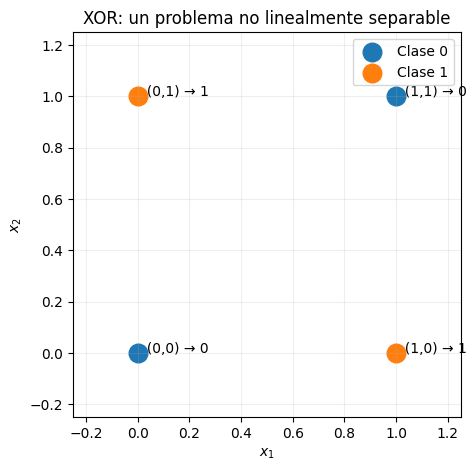

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

fig, ax = plt.subplots(figsize=(5, 5))
for clase in [0, 1]:
    m = y_xor == clase
    ax.scatter(X_xor[m,0], X_xor[m,1], s=180, label=f"Clase {clase}")

for (x1, x2), y in zip(X_xor, y_xor):
    ax.annotate(f"  ({x1},{x2}) → {y}", (x1, x2))

ax.set_xlim(-.25, 1.25)
ax.set_ylim(-.25, 1.25)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("XOR: un problema no linealmente separable")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### 🧪 Ejercicio 3 · XOR en clase

1. Intenta separar las clases con una recta.
2. Explica por qué no es posible.
3. Propón una red mínima con:
   - 2 entradas;
   - al menos una capa oculta;
   - 2 salidas para clasificación.
4. ¿Qué cambia conceptualmente al añadir la capa oculta?

> No es necesario encontrar manualmente todos los pesos. El objetivo es comprender **qué capacidad añade la representación oculta**.

## 4. ¿Cuántos parámetros aprende un MLP?

Para dos capas consecutivas con $n_{in}$ entradas y $n_{out}$ neuronas:

$\text{pesos}=n_{in}\times n_{out}$

$\text{bias}=n_{out}$

Por tanto:

$\text{parámetros}=n_{in}n_{out}+n_{out}$

Para una red completa se suman los parámetros de todas las conexiones.

In [ ]:
def contar_parametros(capas):
    detalle = []
    total = 0
    for i in range(len(capas)-1):
        pesos = capas[i] * capas[i+1]
        bias = capas[i+1]
        subtotal = pesos + bias
        detalle.append((i, capas[i], capas[i+1], pesos, bias, subtotal))
        total += subtotal
    return detalle, total

arquitectura = [64, 256, 128, 10]  # arquitectura del notebook anterior
detalle, total = contar_parametros(arquitectura)

print("Arquitectura:", arquitectura)
for capa, nin, nout, pesos, bias, subtotal in detalle:
    print(f"{nin:>3} → {nout:<3}: pesos={pesos:>6}, bias={bias:>4}, total={subtotal:>6}")
print("TOTAL:", total)

Arquitectura: [64, 256, 128, 10]
 64 → 256: pesos= 16384, bias= 256, total= 16640
256 → 128: pesos= 32768, bias= 128, total= 32896
128 → 10 : pesos=  1280, bias=  10, total=  1290
TOTAL: 50826


### 🧠 Ejercicio 4 · Parámetros

**Sin ejecutar la siguiente celda**, calcula los parámetros de:

- A: `[64, 16, 10]`
- B: `[64, 32, 16, 10]`
- C: `[64, 128, 64, 10]`

Después responde:

1. ¿Cuál tiene más capacidad?
2. ¿Duplicar neuronas duplica necesariamente los parámetros?
3. ¿Una red con más parámetros necesariamente generaliza mejor?

In [ ]:
# Comprobación del ejercicio 4
arquitecturas_ejercicio = {
    "A": [64, 16, 10],
    "B": [64, 32, 16, 10],
    "C": [64, 128, 64, 10],
}

for nombre, capas in arquitecturas_ejercicio.items():
    _, n = contar_parametros(capas)
    print(nombre, capas, "→", f"{n:,}", "parámetros")

A [64, 16, 10] → 1,210 parámetros
B [64, 32, 16, 10] → 2,778 parámetros
C [64, 128, 64, 10] → 17,226 parámetros


## 5. Preparación del experimento con Digits y PySpark

Conservamos el mismo conjunto del notebook anterior: `sklearn.datasets.load_digits`.

Cada observación contiene:

- una imagen de $8\times8$;
- 64 variables de entrada;
- una etiqueta entre 0 y 9.

Usaremos un `Pipeline` para que el escalamiento y el MLP formen una sola unidad y evitar ajustar transformaciones utilizando los datos de prueba.

In [ ]:
# Instalación condicional para Colab/Jupyter
import importlib.util, subprocess, sys

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyspark==3.5.1"])

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.functions import vector_to_array

spark = (
    SparkSession.builder
    .appName("MineriaDatos2027-1-MLP-II")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark:", spark.version)

Spark: 4.0.4


In [ ]:
digits = load_digits()
X = digits.data.astype(float)
y = digits.target.astype(int)

filas = [
    (int(i), Vectors.dense(X[i].tolist()), float(y[i]))
    for i in range(len(y))
]

schema = T.StructType([
    T.StructField("id", T.IntegerType(), False),
    T.StructField("features_raw", VectorUDT(), False),
    T.StructField("label", T.DoubleType(), False),
])

datos = spark.createDataFrame(filas, schema)

entrenamiento, prueba = datos.randomSplit([0.8, 0.2], seed=42)
entrenamiento = entrenamiento.cache()
prueba = prueba.cache()

print("Entrenamiento:", entrenamiento.count())
print("Prueba:", prueba.count())

Entrenamiento: 1472
Prueba: 325


### Exploración del dataset real

Antes de entrenar la red, revisemos la procedencia, dimensiones, distribución de clases y ejemplos concretos. En minería de datos, **conocer los datos precede al modelado**.


In [ ]:
print("Descripción resumida del dataset:")
print(digits.DESCR[:1200])

print("\nDimensiones X:", X.shape)
print("Número de clases:", len(np.unique(y)))
print("Rango de intensidad:", X.min(), "a", X.max())

conteos = pd.Series(y).value_counts().sort_index()
display(pd.DataFrame({"digito": conteos.index, "observaciones": conteos.values}))


Descripción resumida del dataset:
.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted i

,digito,observaciones
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


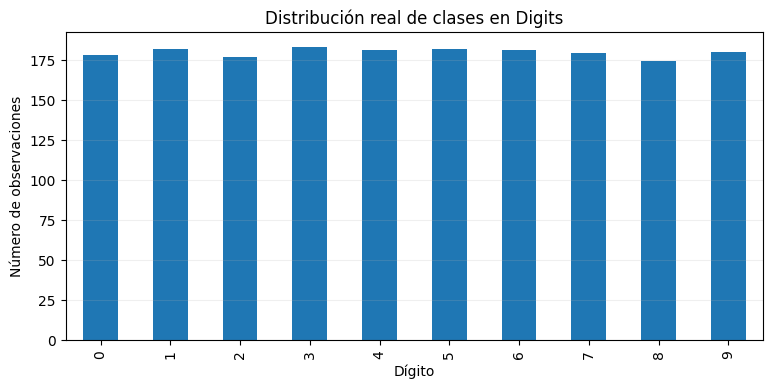

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
conteos.plot(kind="bar", ax=ax)
ax.set_xlabel("Dígito")
ax.set_ylabel("Número de observaciones")
ax.set_title("Distribución real de clases en Digits")
ax.grid(axis="y", alpha=.2)
plt.show()


### 🧪 Ejercicio · Auditoría rápida de datos

A partir de la exploración anterior:

1. ¿El problema está fuertemente desbalanceado?
2. ¿Cuántas variables recibe la capa de entrada?
3. ¿Por qué la salida necesita 10 neuronas?
4. Identifica dos posibles limitaciones de utilizar imágenes de solo $8	imes8$ píxeles.


## 6. Forward propagation: de los píxeles a una predicción

Durante la propagación hacia adelante, cada capa transforma la representación producida por la anterior:

$\mathbf{x} \rightarrow \mathbf{a}^{(1)} \rightarrow \mathbf{a}^{(2)} \rightarrow \hat{\mathbf{y}}$

En clasificación multiclase, la salida permite decidir qué clase recibe la mayor evidencia/probabilidad.

En Spark no necesitamos implementar manualmente este cálculo para entrenar el clasificador, pero comprenderlo es esencial para interpretar la arquitectura.

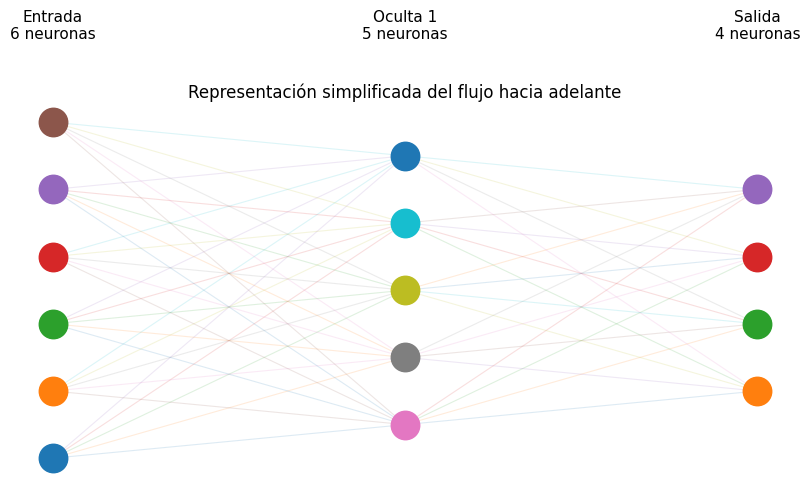

In [ ]:
dibujar_mlp((6, 5, 4), "Representación simplificada del flujo hacia adelante")

## 7. Backpropagation: aprender del error

El entrenamiento compara la salida de la red con la etiqueta real mediante una función objetivo. Después calcula cómo contribuyen los parámetros al error y actualiza los pesos.

De forma conceptual:

$w_{t+1}=w_t-\eta\nabla L(w_t)$

donde:

- $L$: función de pérdida;
- $\nabla L$: gradiente;
- $\eta$: tamaño de paso (*learning rate / step size*);
- $t$: iteración.

Un `stepSize` muy pequeño puede hacer lento el aprendizaje; uno demasiado grande puede provocar actualizaciones inestables.

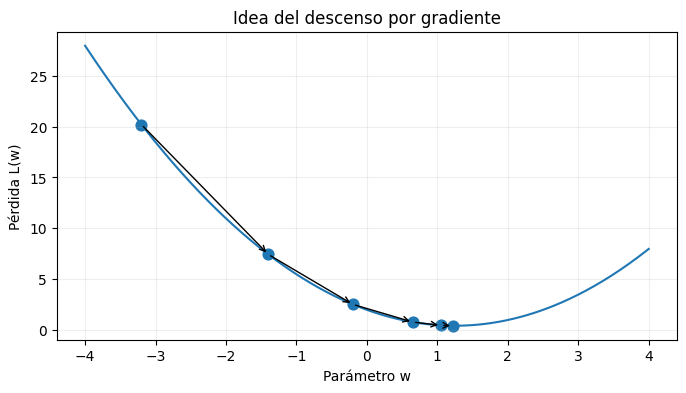

In [ ]:
# Visualización conceptual de descenso por gradiente en una función simple
w = np.linspace(-4, 4, 400)
L = (w - 1.25)**2 + 0.4

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(w, L)
puntos = [-3.2, -1.4, -0.2, 0.65, 1.05, 1.22]
ax.scatter(puntos, [(p-1.25)**2 + .4 for p in puntos], s=60)
for a, b in zip(puntos[:-1], puntos[1:]):
    ax.annotate("", xy=(b, (b-1.25)**2+.4),
                xytext=(a, (a-1.25)**2+.4),
                arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("Parámetro w")
ax.set_ylabel("Pérdida L(w)")
ax.set_title("Idea del descenso por gradiente")
ax.grid(alpha=.2)
plt.show()

### 🧠 Ejercicio 5 · Predice antes de entrenar

Ordena de menor a mayor complejidad:

- `[64, 16, 10]`
- `[64, 256, 128, 10]`
- `[64, 64, 32, 10]`

Luego formula una hipótesis:

> “Espero que ______ obtenga ______ desempeño porque ______.”

Guarda tu hipótesis. La contrastaremos con datos.

## 8. Función reusable para experimentar con MLP

Para comparar arquitecturas debemos mantener constantes:

- los datos;
- la partición;
- el escalamiento;
- la semilla;
- la métrica.

Así, el principal factor que cambia es la configuración que queremos estudiar.

In [ ]:
def entrenar_mlp(capas, max_iter=100, step_size=0.03, block_size=128, seed=42):
    scaler = MinMaxScaler(
        inputCol="features_raw",
        outputCol="features",
        min=0.0,
        max=1.0
    )

    mlp = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        probabilityCol="probability",
        layers=capas,
        maxIter=max_iter,
        stepSize=step_size,
        blockSize=block_size,
        seed=seed
    )

    pipeline = Pipeline(stages=[scaler, mlp])

    inicio = time.perf_counter()
    modelo = pipeline.fit(entrenamiento)
    segundos = time.perf_counter() - inicio

    pred_train = modelo.transform(entrenamiento)
    pred_test = modelo.transform(prueba)

    ev_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    )
    ev_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    )

    _, parametros = contar_parametros(capas)

    return {
        "arquitectura": str(capas),
        "parametros": parametros,
        "accuracy_train": ev_acc.evaluate(pred_train),
        "accuracy_test": ev_acc.evaluate(pred_test),
        "f1_test": ev_f1.evaluate(pred_test),
        "segundos": segundos,
        "modelo": modelo,
        "pred_test": pred_test
    }

## 9. Experimento A · Profundidad y anchura

Compararemos redes pequeñas, medianas y grandes.

> **Importante:** el objetivo no es “ganar” con accuracy, sino estudiar el compromiso entre capacidad, costo y generalización.

In [ ]:
# Para una clase rápida, usa max_iter=60.
# Para resultados más estables, aumenta a 100–150.

arquitecturas = [
    [64, 16, 10],
    [64, 32, 16, 10],
    [64, 64, 32, 10],
    [64, 128, 64, 10],
]

resultados = []

for capas in arquitecturas:
    print("Entrenando:", capas)
    r = entrenar_mlp(capas, max_iter=60, step_size=0.03)
    resultados.append(r)

tabla = pd.DataFrame([
    {k:v for k,v in r.items() if k not in ("modelo", "pred_test")}
    for r in resultados
])

tabla

Entrenando: [64, 16, 10]
Entrenando: [64, 32, 16, 10]
Entrenando: [64, 64, 32, 10]
Entrenando: [64, 128, 64, 10]


,arquitectura,parametros,accuracy_train,accuracy_test,f1_test,segundos
0,"[64, 16, 10]",1210,1.0,0.944615,0.944703,9.151749
1,"[64, 32, 16, 10]",2778,1.0,0.953846,0.953863,5.129225
2,"[64, 64, 32, 10]",6570,1.0,0.944615,0.944434,4.888483
3,"[64, 128, 64, 10]",17226,1.0,0.953846,0.953438,6.043979


0. For me it is very suspicious that the 0 and 2 have EXACTLY the same `accuracy_test` as well as 1 and 3. My professor said this happens because the data size is very small, is this true?

1. When my professor ran the notebook he had the 0 architecture as the shortest and 3 as the longest, why do I have it backwards? While I imagine that there is a difference between using CPU and GPU I still don't see how 0 would take the longest when it is strictly less data.

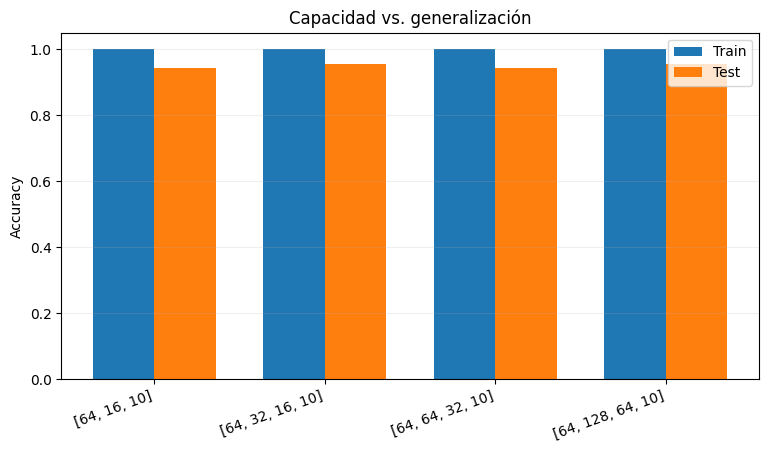

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(tabla))
ancho = .36
ax.bar(x-ancho/2, tabla["accuracy_train"], ancho, label="Train")
ax.bar(x+ancho/2, tabla["accuracy_test"], ancho, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(tabla["arquitectura"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Capacidad vs. generalización")
ax.legend()
ax.grid(axis="y", alpha=.2)
plt.show()

### Ejercicio 6 · Evaluación de arquitecturas

Con los resultados obtenidos:

1. ¿Qué arquitectura obtuvo mayor accuracy de prueba?
2. ¿Cuál tiene menos parámetros?
3. Calcula mentalmente qué modelo elegirías si el costo computacional importara.
4. ¿La arquitectura más grande fue la mejor?
5. Busca una diferencia grande entre `accuracy_train` y `accuracy_test`.
6. ¿Esa diferencia podría ser una señal de sobreajuste?

**Discusión:** una sola ejecución no demuestra que una arquitectura sea universalmente superior.

## 10. Underfitting y overfitting

### Underfitting
El modelo no posee capacidad suficiente o no ha sido entrenado adecuadamente. Su desempeño puede ser bajo incluso sobre entrenamiento.

### Overfitting
El modelo se adapta demasiado a particularidades del entrenamiento y pierde capacidad de generalización.

Una señal útil es la **brecha de generalización**:

$gap = accuracy_{train} - accuracy_{test}$

No es una prueba absoluta de sobreajuste, pero sí una señal para investigar.

In [ ]:
tabla["gap"] = tabla["accuracy_train"] - tabla["accuracy_test"]
tabla[["arquitectura", "parametros", "accuracy_train", "accuracy_test", "gap", "segundos"]]

,arquitectura,parametros,accuracy_train,accuracy_test,gap,segundos
0,"[64, 16, 10]",1210,1.0,0.944615,0.055385,9.151749
1,"[64, 32, 16, 10]",2778,1.0,0.953846,0.046154,5.129225
2,"[64, 64, 32, 10]",6570,1.0,0.944615,0.055385,4.888483
3,"[64, 128, 64, 10]",17226,1.0,0.953846,0.046154,6.043979


### 🧠 Ejercicio 7 · Diagnóstico

Completa:

- Un modelo con bajo `accuracy_train` y bajo `accuracy_test` podría estar __________.
- Un modelo con `accuracy_train` muy alto y prueba considerablemente menor podría estar __________.
- Si dos modelos tienen accuracy similar, pero uno utiliza 10 veces más parámetros, ¿qué información adicional considerarías antes de elegir?

Discute durante 5 minutos.

## 11. Experimento B · Efecto de `stepSize`

Ahora fijamos la arquitectura y modificamos únicamente el tamaño de paso.

Antes de ejecutar, predice qué podría ocurrir con:

- `0.001`
- `0.01`
- `0.03`
- `0.10`

No asumas que el mayor valor será el mejor.

In [ ]:
arquitectura_base = [64, 64, 32, 10]
steps = [0.001, 0.01, 0.03, 0.10]

resultados_step = []

for step in steps:
    print("stepSize =", step)
    r = entrenar_mlp(arquitectura_base, max_iter=60, step_size=step)
    resultados_step.append({
        "stepSize": step,
        "accuracy_train": r["accuracy_train"],
        "accuracy_test": r["accuracy_test"],
        "f1_test": r["f1_test"],
        "segundos": r["segundos"]
    })

tabla_step = pd.DataFrame(resultados_step)
tabla_step

stepSize = 0.001
stepSize = 0.01
stepSize = 0.03
stepSize = 0.1


,stepSize,accuracy_train,accuracy_test,f1_test,segundos
0,0.001,1.0,0.944615,0.944434,3.587123
1,0.010,1.0,0.944615,0.944434,4.038707
2,0.030,1.0,0.944615,0.944434,3.760470
3,0.100,1.0,0.944615,0.944434,3.666072


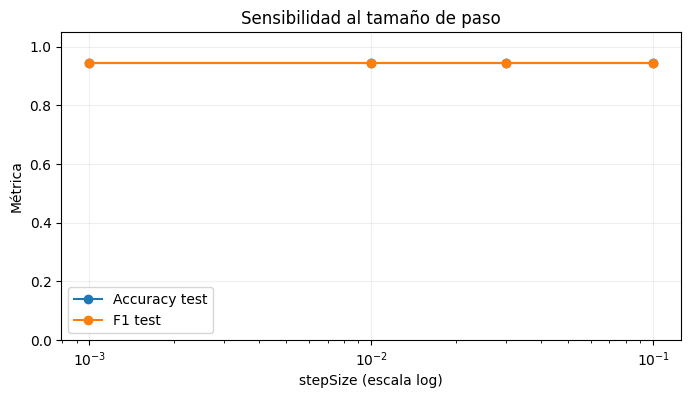

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tabla_step["stepSize"], tabla_step["accuracy_test"], marker="o", label="Accuracy test")
ax.plot(tabla_step["stepSize"], tabla_step["f1_test"], marker="o", label="F1 test")
ax.set_xscale("log")
ax.set_xlabel("stepSize (escala log)")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1.05)
ax.set_title("Sensibilidad al tamaño de paso")
ax.legend()
ax.grid(alpha=.2)
plt.show()

### Ejercicio 8 · Interpreta el optimizador

1. ¿Qué `stepSize` funcionó mejor en esta ejecución?
2. ¿El valor más pequeño fue el mejor?
3. ¿El mayor fue necesariamente inestable?
4. ¿Por qué no debemos generalizar esta conclusión a todos los datasets?
5. ¿Qué interacción podría existir entre `stepSize` y `maxIter`?

## 13. Confianza y análisis de errores

Accuracy no explica **qué** está fallando. Analizaremos:

- predicción;
- probabilidad máxima;
- errores con alta confianza;
- pares de clases confundidos.

La confianza del clasificador no debe interpretarse como probabilidad de que el sistema “tenga razón” en sentido absoluto; es una salida interna del modelo.

In [ ]:
pred = modelo_base["pred_test"]

evaluadas = (
    pred
    .withColumn("probs", vector_to_array("probability"))
    .withColumn("confianza", F.array_max("probs"))
    .withColumn("correcta", (F.col("label") == F.col("prediction")).cast("int"))
)

evaluadas.select("id", "label", "prediction", "confianza", "correcta").show(12, truncate=False)

NameError: name 'modelo_base' is not defined

In [ ]:
errores_conf = (
    evaluadas
    .filter(F.col("correcta") == 0)
    .orderBy(F.desc("confianza"))
    .select("id", "label", "prediction", "confianza", "features_raw")
    .limit(12)
    .collect()
)

fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, fila in zip(axes.ravel(), errores_conf):
    img = np.array(fila["features_raw"]).reshape(8, 8)
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(
        f"Real {int(fila['label'])} → {int(fila['prediction'])}\n"
        f"conf={fila['confianza']:.2f}"
    )
    ax.axis("off")

for ax in axes.ravel()[len(errores_conf):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Ejercicio 10 · Detective de errores

Selecciona tres errores de la figura:

1. ¿El dígito es ambiguo también para una persona?
2. ¿Qué error tiene mayor confianza?
3. ¿Qué es más preocupante: un error con confianza `0.52` o uno con `0.98`? ¿Por qué?
4. Propón una acción para mejorar el sistema:
   - más datos;
   - mejor representación;
   - otra arquitectura;
   - ajuste de entrenamiento;
   - revisión de ejemplos difíciles.

Justifica tu elección.

## 14.Diseña tu propio MLP

### Restricciones

Diseña una arquitectura que cumpla:

- entrada: 64;
- salida: 10;
- máximo 3 capas ocultas;
- máximo **25 000 parámetros entrenables**;
- `maxIter ≤ 100`.

### Objetivo

No se busca únicamente maximizar accuracy. Debes justificar el compromiso entre:

- desempeño;
- número de parámetros;
- tiempo;
- brecha train/test;
- comportamiento de los errores.

### Antes de ejecutar

Escribe:

1. arquitectura propuesta;
2. número esperado de parámetros;
3. `stepSize`;
4. hipótesis sobre su desempeño.

In [ ]:
# ============================================================
# RETO FINAL - COMPLETAR EN CLASE
# ============================================================

MI_ARQUITECTURA = [64, 32, 16, 10]   # <-- MODIFICA
MI_STEP_SIZE = 0.03                    # <-- MODIFICA
MI_MAX_ITER = 60                       # <-- MODIFICA

### Entregable del reto

Completa esta ficha en una celda Markdown:

**Arquitectura:**  
**Parámetros:**  
**stepSize:**  
**maxIter:**  
**Accuracy train:**  
**Accuracy test:**  
**F1 test:**  
**Tiempo:**  
**Brecha train-test:**  

**Conclusión (3–5 líneas):**  
¿Conservarías este modelo? Explica por qué utilizando evidencia del experimento.

## Caso real adicional · Diagnóstico de cáncer de mama

Un MLP no se limita a imágenes. Para comprobarlo utilizaremos el dataset **Breast Cancer Wisconsin (Diagnostic)** distribuido con scikit-learn.

Las variables fueron calculadas a partir de imágenes digitalizadas de aspirados con aguja fina de masas mamarias y describen propiedades de los núcleos celulares. El objetivo es distinguir entre muestras **malignas** y **benignas**.

> Este ejercicio tiene propósito exclusivamente educativo. No constituye un sistema clínico ni debe utilizarse para tomar decisiones médicas.


In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame.copy()

print("Observaciones:", df_cancer.shape[0])
print("Variables predictoras:", len(cancer.feature_names))
print("Clases:", dict(enumerate(cancer.target_names)))
df_cancer.head()


Observaciones: 569
Variables predictoras: 30
Clases: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


3. First of all I don't know many neurons should I have in total. It seems that it is the number of variables, so I should have at least 32 entry variables. While most people partition the numbers as the amount of layers continue I think that a single hidden layer of 32 neurons would be enough to result simply in 2 output neurons (bening and malign).

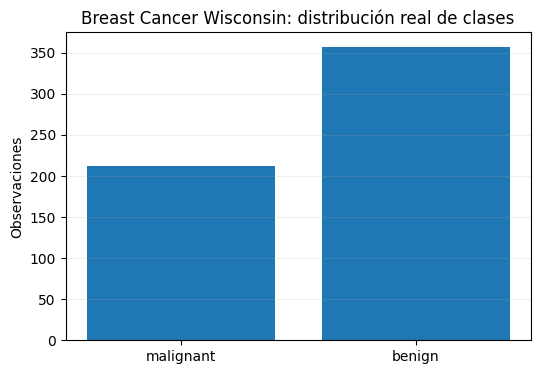

In [ ]:
conteo_cancer = df_cancer["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([cancer.target_names[i] for i in conteo_cancer.index], conteo_cancer.values)
ax.set_ylabel("Observaciones")
ax.set_title("Breast Cancer Wisconsin: distribución real de clases")
ax.grid(axis="y", alpha=.2)
plt.show()


4. The amount of data is unbalanced, so I believe that there should be some cut... but if I simply put an artificial dataset of 400 observations in which half are malignant, half are bening and I use 320 observations for training and 80 for test wouldn't that skew the model into believing that malignant labels are much more common that they're? I believe this might not be a problem and that in fact it could be beneficial, as I am teaching the model to recognize, not to simply use its knowledge about proportions to "guess" how many are bening and how many are malignant.

### 🧪 Ejercicio · Diseña el MLP antes de programarlo

Con este dataset:

1. ¿Cuántas neuronas debe tener la capa de entrada?
2. ¿Cuántas debe tener la salida?
3. Propón una arquitectura con una o dos capas ocultas.
4. Calcula sus parámetros entrenables.
5. ¿Usarías únicamente `accuracy` para evaluar este problema? Justifica.


In [ ]:
# Definir dimensiones
input_dim = len(cancer.feature_names)
output_dim = 2

In [ ]:
# Definir la arquitectura
architecture = [32, 16, 2]
print("Arquitectura:", architecture[0] * architecture[1] + 32 * architecture[2])

Arquitectura: 576


5. I don't know how to define the architecture... in pyspark there is only multilayer preceptons right?

```python
arquitectura = [64, 256, 128, 10]  # arquitectura del notebook anterior
detalle, total = contar_parametros(arquitectura)

print("Arquitectura:", arquitectura)
for capa, nin, nout, pesos, bias, subtotal in detalle:
    print(f"{nin:>3} → {nout:<3}: pesos={pesos:>6}, bias={bias:>4}, total={subtotal:>6}")
print("TOTAL:", total)
```

6. It seems I was mistaken, I can actually do with 32, 16 and 2... but did I did the calculation correctly? I don't see the reason behind why I need the 16 * 2 at the end.

```python
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.functions import vector_to_array

spark = (
    SparkSession.builder
    .appName("MineriaDatos2027-1-MLP-II")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark:", spark.version)
```

In [ ]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import MinMaxScaler
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.functions import vector_to_array

7. I don't know how many of these do we need, but at least with the `MulticlassClassificationEvaluator` I feel it is enough


In [ ]:
filas = [
    (int(i), Vectors.dense(X[i].tolist()), float(y[i]))
    for i in range(len(y))
]

schema = T.StructType([
    T.StructField("id", T.IntegerType(), False),
    T.StructField("df_cancer.mean_radius", VectorUDT(), False),
    T.StructField("df_cancer.mean_texture", T.DoubleType(), False),
])
'''9. I might need to modify just this schema with the
 cancer dataframe. Why
each of these are in `False`? I don't have id in
`cancer_dataframe`. '''

'''10. Even when I changed the names of `T.struct`
nothing seemed to change... what is a T.struct?
I imagine it must be a "Tensor Structure"... it seems
that the name doesn't has anything to do with the
actual dataframe. '''

'''11. My professor told me that I need to separate my
X and my Y, in which I assume X is the random variable
that describes the inputs and Y is the random variable
that describes the output. '''

'''12. Something that I wonder is if multilayer perceptron
is actually a legit machine learning algorithm or we're
just forcing it to work with things that they don't
normally have (such as backpropragation) ashhas'''

datos_cancer = spark.createDataFrame(filas, schema)

entrenamiento_cancer, prueba_cancer = datos_cancer.randomSplit([0.8, 0.2], seed=42)
entrenamiento_cancer = entrenamiento.cache()
prueba_cancer = prueba.cache()

print("Entrenamiento:", entrenamiento.count())
print("Prueba:", prueba.count())

Entrenamiento: 1472
Prueba: 325


8. I don't know how to put the data about the cancer... I actually feel my architecture is wrong as I need 30*569 neurons, don't I?